# Wavelet Scattering Transform Examples

This notebook demonstrates how to use the Wavelet Scattering Transform (WST) estimator from the ACM package.

The WST is a powerful tool for extracting non-Gaussian information from galaxy density fields through a combination of wavelet decomposition and statistical moments.

In [2]:
from pathlib import Path
import glob
import fitsio
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

from acm.estimators.galaxy_clustering.wst import WaveletScatteringTransform
from acm import setup_logging

def get_hod_fns(cosmo=1, phase=0, redshift=0.5, seed=0):
    """
    Get the list of HOD file names for a given cosmology,
    phase, and redshift.
    """
    base_dir = '/pscratch/sd/n/ntbfin/emulator/hods/z0.5/yuan23_prior/'
    hod_dir = Path(base_dir) / f'c{cosmo:03}_ph{phase:03}/seed{seed}/'
    hod_fns = glob.glob(str(Path(hod_dir) / f'hod*.fits'))
    return sorted(hod_fns)

def get_hod_positions(filename, los='z'):
    """Get redshift-space positions from a HOD file."""
    hod, header = fitsio.read(filename, header=True)
    qpar, qperp = header['Q_PAR'], header['Q_PERP']
    if los == 'x':
        pos = np.c_[hod['X_RSD'], hod['Y_PERP'], hod['Z_PERP']]
        boxsize = np.array([2000/qpar, 2000/qperp, 2000/qperp])
    elif los == 'y':
        pos = np.c_[hod['X_PERP'], hod['Y_RSD'], hod['Z_PERP']]
        boxsize = np.array([2000/qperp, 2000/qpar, 2000/qperp])
    elif los == 'z':
        pos = np.c_[hod['X_PERP'], hod['Y_PERP'], hod['Z_RSD']]
        boxsize = np.array([2000/qperp, 2000/qperp, 2000/qpar])
    return pos, boxsize

def get_box_args(boxsize, cellsize):
    meshsize = (boxsize / cellsize).astype(int)
    return dict(boxsize=boxsize, boxcenter=0.0, meshsize=meshsize)


setup_logging()

# load galaxy catalog for testing
hod_fn = get_hod_fns(cosmo=0, phase=0, redshift=0.5)[0]
positions, boxsize = get_hod_positions(hod_fn, los='z')

## Basic WST Computation

The WST estimator computes scattering coefficients that capture non-Gaussian features of the density field.

In [4]:
# Set up the WST estimator
# Using a larger cellsize (e.g., 100 Mpc/h) for the WST computation
box_args = get_box_args(boxsize, cellsize=100)

# Instantiate the WaveletScatteringTransform class
wst = WaveletScatteringTransform(data_positions=positions, backend='jaxpower', **box_args)

# Set the density contrast field
wst.set_density_contrast()

# Compute WST coefficients
coefficients = wst.run()

print(f"Number of WST coefficients: {len(coefficients)}")
print(f"First 10 coefficients: {coefficients[:10]}")

[000013.44]  01-27 18:50  JaxpowerBackend              INFO     Box size: [2000. 2000. 2000.]
[000013.44]  01-27 18:50  JaxpowerBackend              INFO     Box center: [0. 0. 0.]
[000013.44]  01-27 18:50  JaxpowerBackend              INFO     Box meshsize: [20 20 20]
[000013.44]  01-27 18:50  WaveletScatteringTransform   INFO     Using JaxpowerBackend backend.
[000013.45]  01-27 18:50  JaxpowerBackend              INFO     Generated lattice query points in 0.01 s.
[000013.45]  01-27 18:50  WaveletScatteringTransform   INFO     Initializing WaveletScatteringTransform.
[000013.45]  01-27 18:50  WaveletScatteringTransform   INFO     J=4, L=4, sigma_0=0.8, max_order=2
[000014.71]  01-27 18:50  WaveletScatteringTransform   INFO     Initialized Kymatio in 1.26 s.
[000014.72]  01-27 18:50  JaxpowerBackend              INFO     Set density contrast in 0.01 s.
[000015.11]  01-27 18:50  WaveletScatteringTransform   INFO     WST coefficients done in 0.39 s.
Number of WST coefficients: 76
First 

## Visualizing WST Coefficients

Let's plot the scattering coefficients to see the distribution of wavelet features.

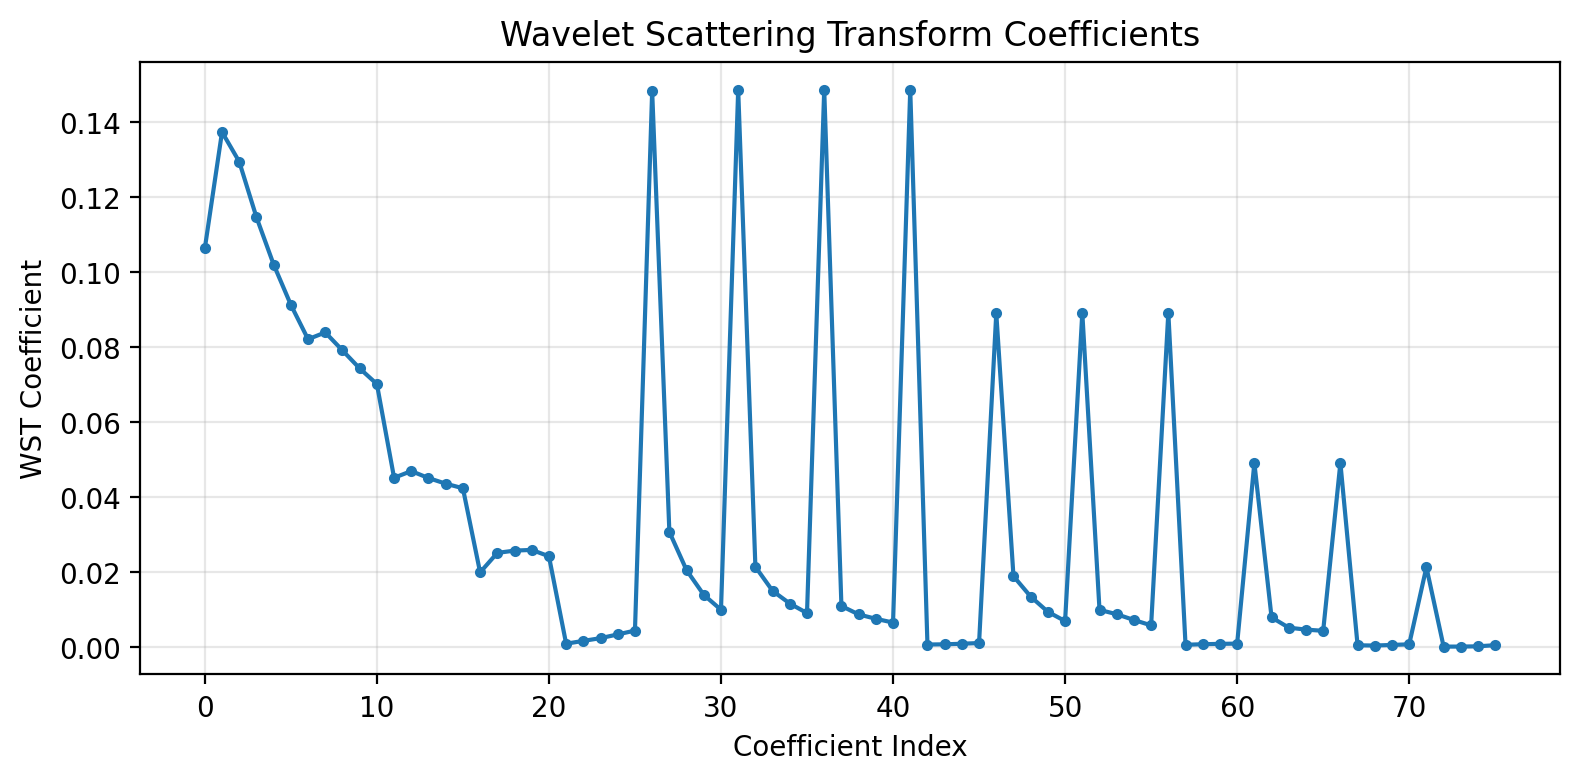

In [5]:
# Plot the WST coefficients
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(coefficients, 'o-', markersize=3)
ax.set_xlabel('Coefficient Index')
ax.set_ylabel('WST Coefficient')
ax.set_title('Wavelet Scattering Transform Coefficients')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Density Contrast Field

We can also visualize the underlying density contrast field used for the WST computation.

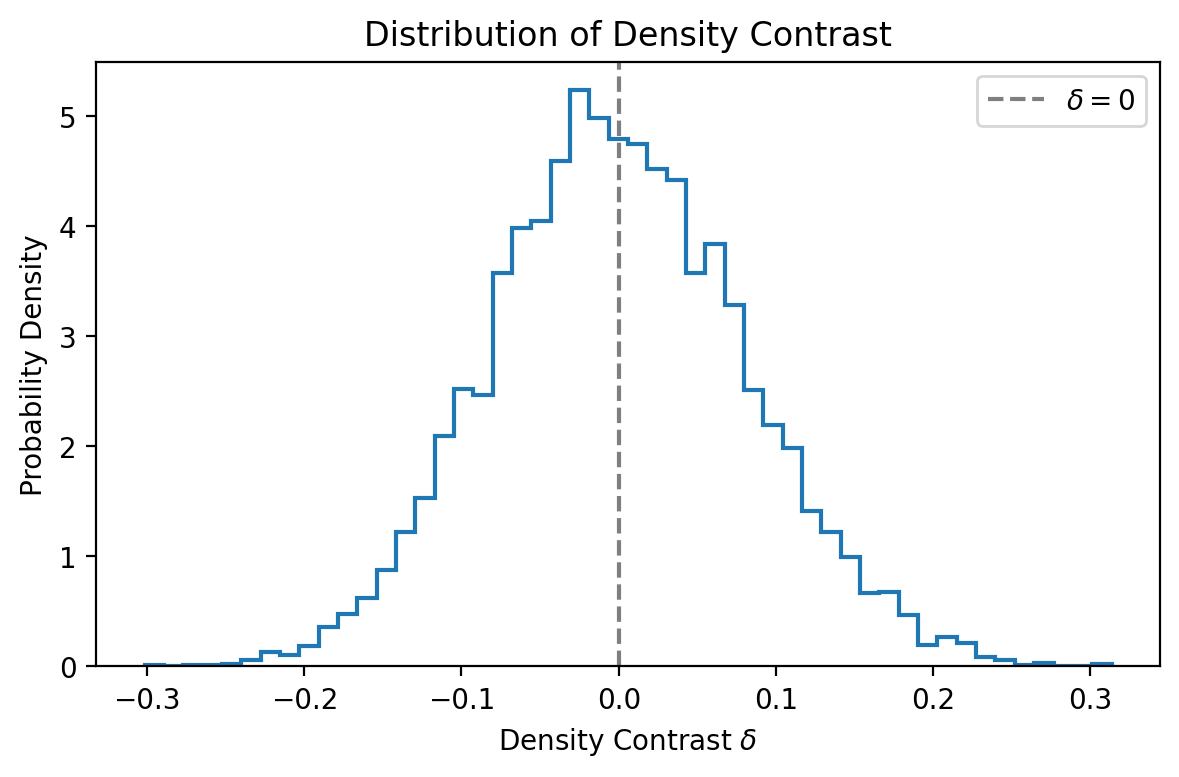

In [6]:
# Access the density contrast field
delta = wst.delta_query

# Plot histogram of density values
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(delta.flatten(), bins=50, density=True, histtype='step', linewidth=1.5)
ax.set_xlabel('Density Contrast $\\delta$')
ax.set_ylabel('Probability Density')
ax.set_title('Distribution of Density Contrast')
ax.axvline(0, color='k', linestyle='--', alpha=0.5, label='$\\delta = 0$')
ax.legend()
plt.tight_layout()
plt.show()

## Comparing Different Backends

The WST estimator supports both `jaxpower` and `pypower` backends. Let's compare them.

[000042.92]  01-27 18:50  JaxpowerBackend              INFO     Box size: [2000. 2000. 2000.]
[000042.92]  01-27 18:50  JaxpowerBackend              INFO     Box center: [0. 0. 0.]
[000042.93]  01-27 18:50  JaxpowerBackend              INFO     Box meshsize: [20 20 20]
[000042.93]  01-27 18:50  WaveletScatteringTransform   INFO     Using JaxpowerBackend backend.
[000042.93]  01-27 18:50  JaxpowerBackend              INFO     Generated lattice query points in 0.01 s.
[000042.93]  01-27 18:50  WaveletScatteringTransform   INFO     Initializing WaveletScatteringTransform.
[000042.94]  01-27 18:50  WaveletScatteringTransform   INFO     J=4, L=4, sigma_0=0.8, max_order=2
[000044.21]  01-27 18:50  WaveletScatteringTransform   INFO     Initialized Kymatio in 1.28 s.
[000044.22]  01-27 18:50  JaxpowerBackend              INFO     Set density contrast in 0.01 s.
[000044.77]  01-27 18:50  WaveletScatteringTransform   INFO     WST coefficients done in 0.54 s.
[000045.04]  01-27 18:50  PypowerBack

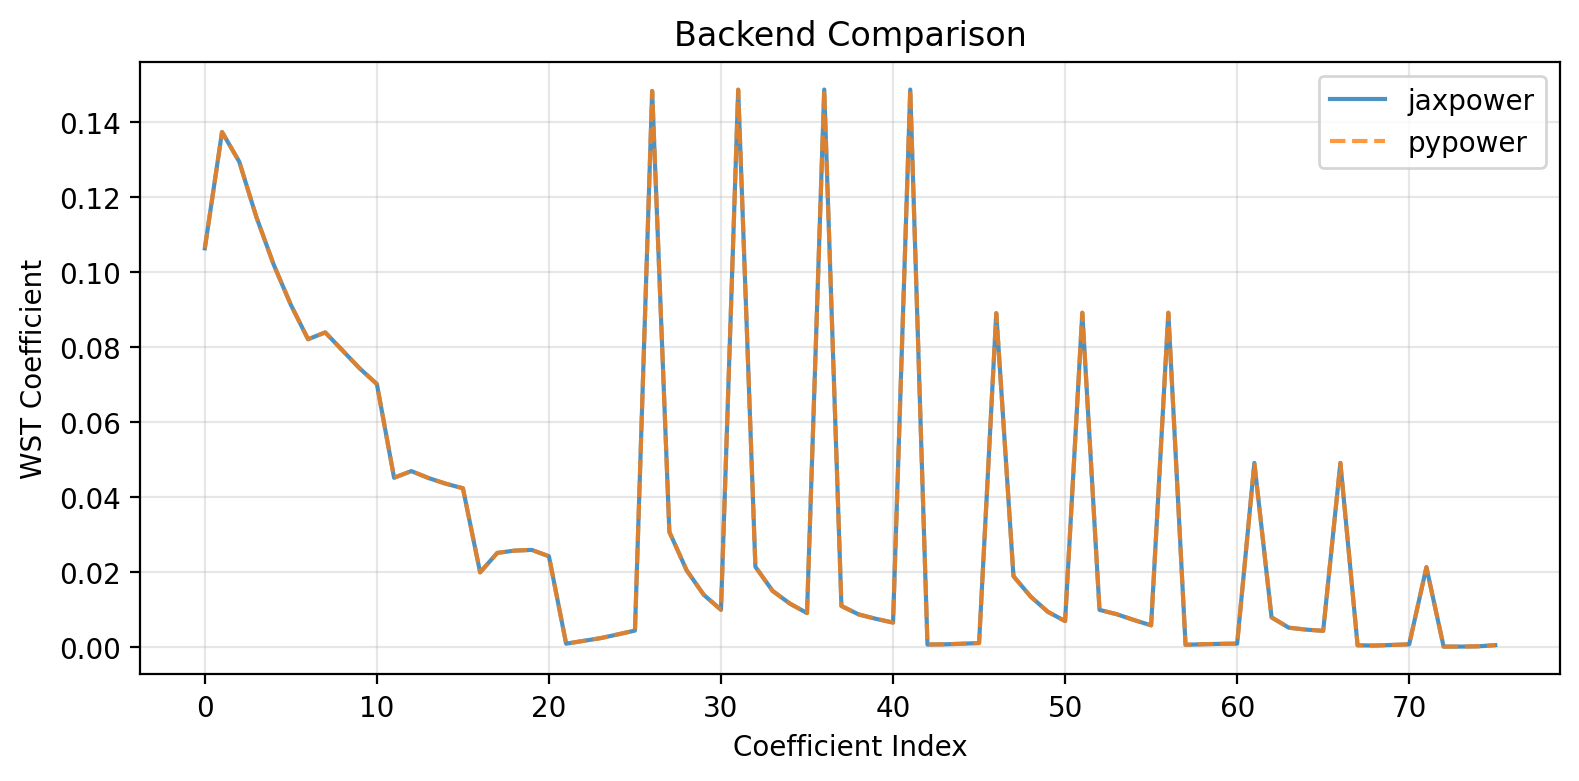

In [7]:
# Compute WST with both backends
backends = ['jaxpower', 'pypower']
coeffs_dict = {}

for backend in backends:
    wst = WaveletScatteringTransform(data_positions=positions, backend=backend, **box_args)
    wst.set_density_contrast()
    coeffs_dict[backend] = wst.run()

# Plot comparison
fig, ax = plt.subplots(figsize=(8, 4))
for backend, coeffs in coeffs_dict.items():
    ls = '-' if backend == 'jaxpower' else '--'
    ax.plot(coeffs, label=backend, ls=ls, alpha=0.8)
ax.set_xlabel('Coefficient Index')
ax.set_ylabel('WST Coefficient')
ax.set_title('Backend Comparison')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()